Row,Stitch count
0,31
1,33
2,36
3,41
4,47
5,53
6,58
7,62
8,63


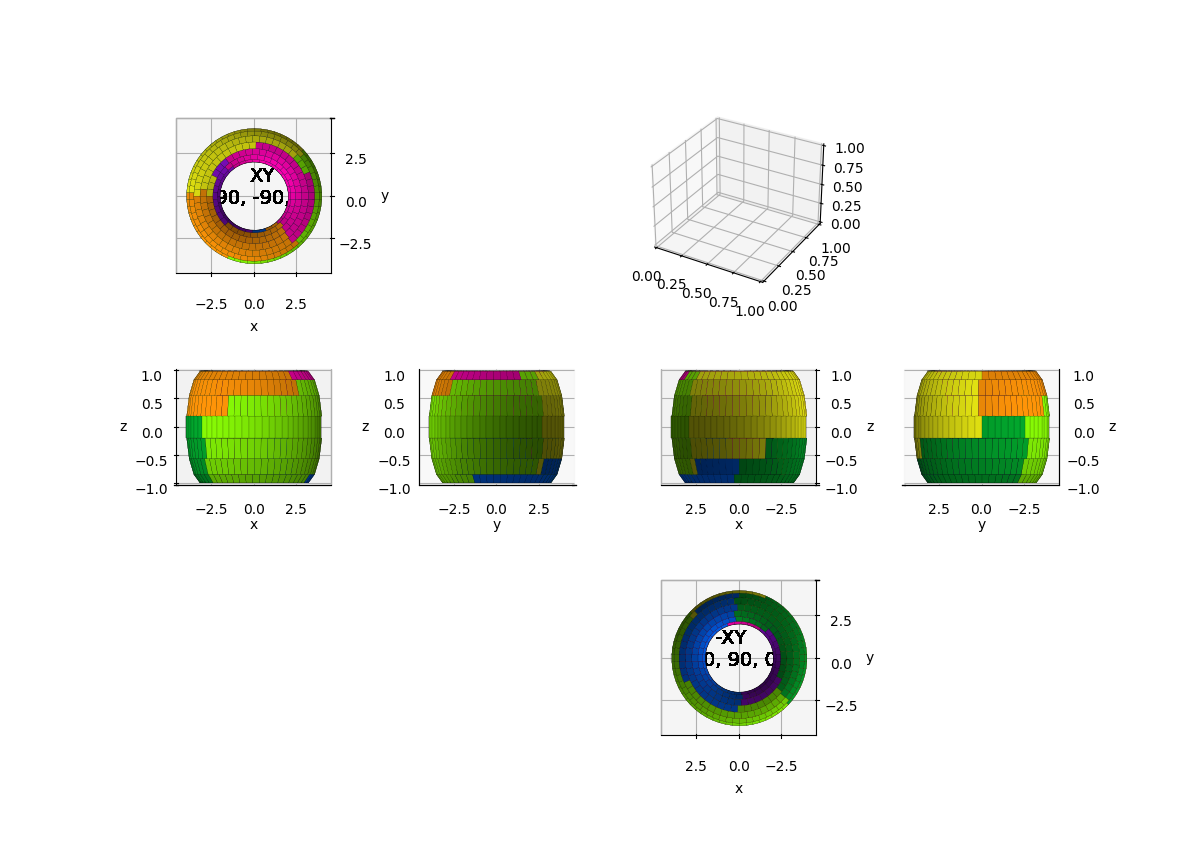

In [1]:
from tabulate import tabulate

import numpy as np

from mpl_toolkits import mplot3d
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS, same_color
%matplotlib ipympl

R = 3
r = 1
w = .4
h = .4

# Pattern instructions
N = round(r * np.pi/h)
st_count = [0]*(int(N)+1)
pattern = [0]*(int(N)+1)
row = [0]*(int(N)+1)
for n in range(int(N)+1):
    st_count[n]=round(2*np.pi*(R-r*np.cos(n*np.pi/int(N)))/w)
    row[n] = n #"Row "+str(n)+": "+str(st_count[n])+" st."

# Stitch count table
table = np.transpose([row, st_count])
pattern = tabulate(table,headers=["Row","Stitch count"],tablefmt="html")
display(pattern)

# Pattern model
#fig = plt.figure(figsize = (10,10),label=' ')
#ax = plt.axes(projection='3d')
#ax.grid()
# (plane, (elev, azim, roll))
def annotate_axes(ax, text, fontsize=18):
    ax.text(x=0.5, y=0.5, z=0.5, s=text,
            va="center", ha="center", fontsize=fontsize, color="black")
views = [('XY',   (90, -90, 0)),
         ('XZ',    (0, -90, 0)),
         ('YZ',    (0,   0, 0)),
         ('-XY', (-90,  90, 0)),
         ('-XZ',   (0,  90, 0)),
         ('-YZ',   (0, 180, 0))]

layout = [['XY',  '.',   'L',   '.'],
          ['XZ', 'YZ', '-XZ', '-YZ'],
          ['.',   '.', '-XY',   '.']]
fig, axd = plt.subplot_mosaic(layout, subplot_kw={'projection': '3d'},
                              figsize=(12, 8.5))

c = [
    'gray',
    'xkcd:bright pink',
    'xkcd:lime green',
    'xkcd:yellow',
    'xkcd:violet',
    'xkcd:tangerine',
    'xkcd:kelly green',
    'xkcd:bright blue'
]  

colours = [0]*(N+1)

# UPPER
for n in range(int(N)+1):
    colours[n] = [c[0] for i in range(st_count[n])]
    for k in range(0,st_count[n]):
        theta = (n+.5)*np.pi/N
        phi = (k+.5)*2*np.pi/st_count[n] # slight offset to better reflect crochet stitch distribution
        
        m=-(2/3)*N/st_count[n]
        L1 = m*k+(2/3)*N
        L2 = m*k+(4/3)*N
        L3 = m*k+2*N
        if phi <= np.pi/4:
            if n<=L1:
                colours[n][k] = c[1]
            elif L1<=n<=L2:
                colours[n][k] = c[2]
            
        
        elif np.pi/4 <= phi <= 3*np.pi/4:
            
            if n<=L1:
                colours[n][k] = c[1]
            elif L1<=n<=L2:
                colours[n][k] = c[3]
            
    
        elif 3*np.pi/4 <= phi <= np.pi:
            
            if n<=L1:
                colours[n][k] = c[4]
            elif L1<=n<=L2:
                colours[n][k] = c[3]
            
           
        elif np.pi <= phi <= 5*np.pi/4:
            
            if n<=L1:
                colours[n][k] = c[4]
            elif L1<=n<=L2:
                colours[n][k] = c[5]
            elif L2<=n:
                colours[n][k] = c[6]
            
            
        elif 5*np.pi/4 <= phi <= 3*np.pi/2:
            
            if n<=L1:
                colours[n][k] = c[4]
            elif L1<=n<=L2:
                colours[n][k] = c[5]
            elif L2<=n:
                colours[n][k] = c[2]
            
           
        elif 3*np.pi/2 <= phi <= 7*np.pi/4:
            
            if n<=L1:
                colours[n][k] = c[7]
            elif L1<=n<=L2:
                colours[n][k] = c[5]
            elif L2<=n:
                colours[n][k] = c[2]
            
           
        elif 3*np.pi/2 <= phi <= 2*np.pi:
            
            if n<=L1:
                colours[n][k] = c[7]
            elif L1<=n<=L2:
                colours[n][k] = c[1]
            elif L2<=n:
                colours[n][k] = c[2]
        
        u = np.linspace((n-.5)*np.pi/N, (n+.5)*np.pi/N, 2)
        v = np.linspace((k-.5)*2*np.pi/st_count[n], (k+.5)*2*np.pi/st_count[n], 2)
        u, v = np.meshgrid(u, v)
        x = (R-r*np.cos(u))*np.cos(v)
        y = (R-r*np.cos(u))*np.sin(v)
        z = r*np.sin(u)
        if n==0:
            lw=.5
        else:
            lw=.1
            
        for plane, angles in views:
            axd[plane].set_xlabel('x')
            axd[plane].set_ylabel('y')
            axd[plane].set_zlabel('z')
            axd[plane].set_proj_type('ortho')
            axd[plane].view_init(elev=angles[0], azim=angles[1], roll=angles[2])
            axd[plane].set_box_aspect(None, zoom=1.25)
        
            label = f'{plane}\n{angles}'
            annotate_axes(axd[plane], label, fontsize=14)
            axd[plane].plot_surface(x, y, z, color=colours[n][k], edgecolor='black', linewidth=lw)
        
        
            

# LOWER
for n in range(1,int(N)):
    colours[n] = ['yellow' for i in range(st_count[n])]
    for k in range(0,st_count[n]):
        phi = (k+.5)*2*np.pi/st_count[n]
        
        m=(2/3)*N/st_count[n]
        L1 = m*k
        L2 = m*k+(2/3)*N
        L3 = m*k+(4/3)*N
        
        if phi <= np.pi/4:
            
            # n=m*k+(2/3)*N
            m=(2/3)*N/st_count[n]
            L1 = m*k
            L2 = m*k+(2/3)*N
            L3 = m*k+(4/3)*N
            if n<=L1:
                colours[n][k] = c[1]
            elif L1<=n<=L2:
                colours[n][k] = c[7]
            elif L2<=n<=L3:
                colours[n][k] = c[2]
            
    
        elif np.pi/4 <= phi <= np.pi/2:
            
            if n<=L1:
                colours[n][k] = c[1]
            elif L1<=n<=L2:
                colours[n][k] = c[7]
            elif L2<=n<=L3:
                colours[n][k] = c[3]
            
    
        elif np.pi/2 <= phi <= 3*np.pi/4:
            
            if n<=L1:
                colours[n][k] = c[1]
            elif L1<=n<=L2:
                colours[n][k] = c[6]
            elif L2<=n<=L3:
                colours[n][k] = c[3]
            
        
        elif 3*np.pi/4 <= phi <= np.pi:
            
            if n<=L1:
                colours[n][k] = c[4]
            elif L1<=n<=L2:
                colours[n][k] = c[6]
            elif L2<=n<=L3:
                colours[n][k] = c[3]
            
    
        elif np.pi <= phi <= 5*np.pi/4:
            
            if n<=L1:
                colours[n][k] = c[4]
            elif L1<=n<=L2:
                colours[n][k] = c[6]
            
    
        elif 5*np.pi/4 <= phi <= 3*np.pi/2:
            
            if n<=L1:
                colours[n][k] = c[4]
            elif L1<=n<=L2:
                colours[n][k] = c[2]
            
    
        elif 3*np.pi/2 <= phi <= 2*np.pi:
            
            if n<=L1:
                colours[n][k] = c[7]
            elif L1<=n<=L2:
                colours[n][k] = c[2]
        
        u = np.linspace((-n-.5)*np.pi/N, (-n+.5)*np.pi/N, 2)
        v = np.linspace((k-.5)*2*np.pi/st_count[n], (k+.5)*2*np.pi/st_count[n], 2)
        u, v = np.meshgrid(u, v)
        x = (R-r*np.cos(u))*np.cos(v)
        y = (R-r*np.cos(u))*np.sin(v)
        z = r*np.sin(u)
        for plane, angles in views:
            axd[plane].set_xlabel('x')
            axd[plane].set_ylabel('y')
            axd[plane].set_zlabel('z')
            axd[plane].set_proj_type('ortho')
            axd[plane].view_init(elev=angles[0], azim=angles[1], roll=angles[2])
            axd[plane].set_box_aspect(None, zoom=1.25)
        
            label = f'{plane}\n{angles}'
            annotate_axes(axd[plane], label, fontsize=14)
            axd[plane].plot_surface(x, y, z, color=colours[n][k], edgecolor='black', linewidth=.1)


# Axis labels
#ax.set_xlabel('x', labelpad=20)
#ax.set_ylabel('y', labelpad=20)
#ax.set_zlabel('z', labelpad=20)
for plane in ('XY', '-XY'):
    axd[plane].set_zticklabels([])
    axd[plane].set_zlabel('')
for plane in ('XZ', '-XZ'):
    axd[plane].set_yticklabels([])
    axd[plane].set_ylabel('')
for plane in ('YZ', '-YZ'):
    axd[plane].set_xticklabels([])
    axd[plane].set_xlabel('')
        
label = 'mplot3d primary view planes\n' + 'ax.view_init(elev, azim, roll)'
#annotate_axes(axd['L'], label, fontsize=18)
#axd['L'].set_axis_off()

# Axis limits
#ax.set(zlim=(-R-r,R+r))
    
#ax.set_aspect('equal')

plt.show()